---
title: Time Series Analysis
jupyter: python3
execute:
  cache: true
---

## Exploring Time Series Data

One of the first things that we do when we are given a time series is visualise
it. The visualisation is meant to give us an indication of what kinds of
techniques would be suitable for forecasting it. In this section, we shall
learn several methods to visualise a time series dataset. 

When we visualise a time series, we look out for the following features:    

1. **Trend**: A trend exists when there is a long-term increase or decrease in the data.
2. **Level**: The level of a series refers to its height on the ordinate axis.
3. **Seasonal**: A seasonal pattern exists when a series is influenced by
   factors such as quarters of the year, the month, the day of the week, or time
   of day. Seasonality is always of a **fixed and known** period.
4. **Cyclic**: A cyclic pattern exists when there are rises and falls that are not of a fixed period.

In [1]:
import pandas as pd
import numpy as np
import datetime, calendar
from statsmodels.tsa.seasonal import seasonal_decompose,STL
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.forecasting.theta import ThetaModel
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace import exponential_smoothing

from statsmodels.tsa.api import ( 
  ExponentialSmoothing, SimpleExpSmoothing, Holt, STLForecast
) 

import pmdarima as pm

from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist,squareform

from ind5003 import ts

import matplotlib.pyplot as plt
import seaborn as sns

::: {#exm-housing-1 style="background-color: #D5D1D164; padding: 20px"}
### Basic plots of housing Data
\index{Housing Sales!Basic Plots}

This dataset comes from an R package
[`fma`](https://www.rdocumentation.org/packages/fma/versions/2.5/topics/hsales).
It contains counts of monthly sales of new one-family houses sold in the USA
since 1973.

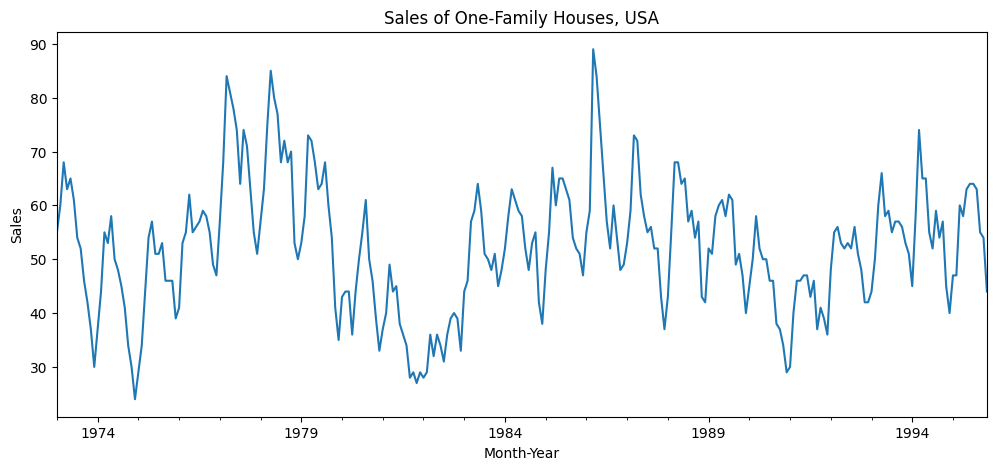

In [2]:
#| fig-align: center

hsales = pd.read_csv('data/hsales.csv', parse_dates=[0])
hsales.set_index('date', inplace=True)
hsales.index.freq = 'MS'
hsales.plot(title='Sales of One-Family Houses, USA', legend=False, figsize=(12,5))
plt.xlabel('Month-Year'); plt.ylabel('Sales');

We observe a strong seasonality within each year. There is some indication of
cyclic behaviour every 6 -- 10 years. There is no apparent monotonic trend over
this period. With pandas objects, we can resample the series. This allows us to
compute summaries over time windows that could be of business importance. For
instance, we might be interested in a breakdown by quarters instead of months. 

:::

With the `resample()` function, we can perform both downsampling (reducing the
frequency of observations) or upsampling (via interpolation or nearest
neighbour imputation).

In [3]:
hsales.resample('14D').interpolate().head()

,hsales
date,
1973-01-01,55.000000
1973-01-15,56.666667
1973-01-29,58.333333
1973-02-12,62.666667
1973-02-26,65.333333


::: {.callout-note}

See the [page](https://pandas.pydata.org/docs/user_guide/timeseries.html#dateoffset-objects)
on date-offset objects for details and options on the strings that you can put
within the resample method. 

:::

::: {#exm-housing-2 style="background-color: #D5D1D164; padding: 20px"}
### Season plots of housing data
\index{Housing Sales!Season Plot}

A season plot allows us to visualise what happens within a season. In this case,
each line in the graph below traces the behaviour of the series from the
beginning of the season till the end (from Jan to Dec).

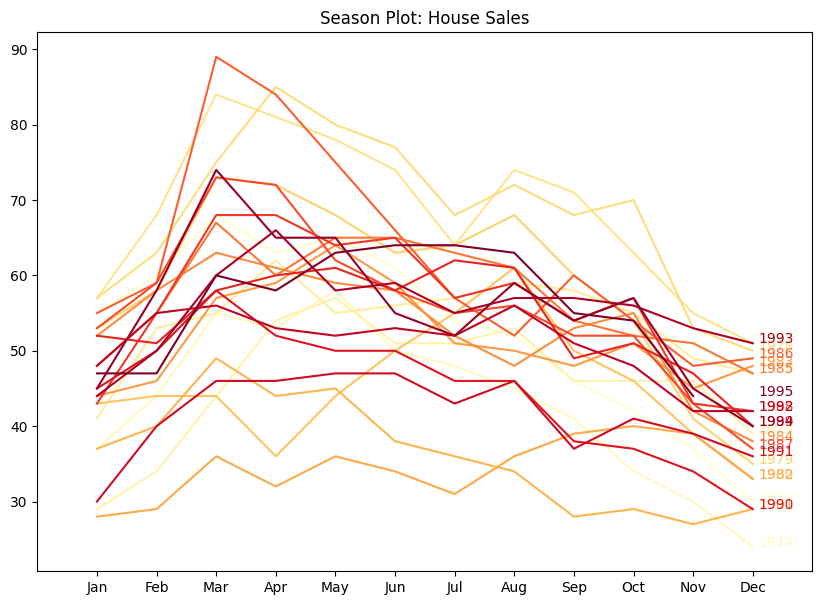

In [4]:
#| fig-align: center
#| fig-cap: "Season plot of housing sales"
#| label: fig-season-sales

hsales.loc[:, 'year'] = hsales.index.year
hsales.loc[:, 'month'] = hsales.index.month

yrs = np.sort(hsales.year.unique())
color_ids = np.linspace(0, 1, num=len(yrs))
colors_to_use = plt.cm.YlOrRd(color_ids)

plt.figure(figsize=(10, 7))

for i,yr in enumerate(yrs):
    df_tmp = hsales.loc[hsales.year == yr, :]
    plt.plot(df_tmp.month, df_tmp.hsales, color=colors_to_use[i]);
    plt.text(12.1, df_tmp.hsales.iloc[-1], str(yr), color=colors_to_use[i])
plt.title('Season Plot: House Sales')
plt.xlim(0, 13)
plt.xticks(np.arange(1, 13), calendar.month_abbr[1:13]);

:::

In general, from @fig-season-sales, it looks like there is a peak around Feb to
March, after which sales descend until the next January. Using a colour map with
colours that we can "order" allows us to identify a trend **across** seasons. In
this case, there isn't one, but if you take a look at @fig-season-qauselec, you
will see a clear association between the colour of line and level of each series
within a year.

::: {#exm-aus-elec-1 style="background-color: #D5D1D164; padding: 20px"}
### Australian quarterly electricity production
\index{Australian QEC!Basic Plots} 

This dataset is from another R package: [`fpp2`](https://www.rdocumentation.org/packages/fpp2/versions/2.5/topics/qauselec).
It records quarterly electric production in Australia (in billion kWh) from 1965 
till now.

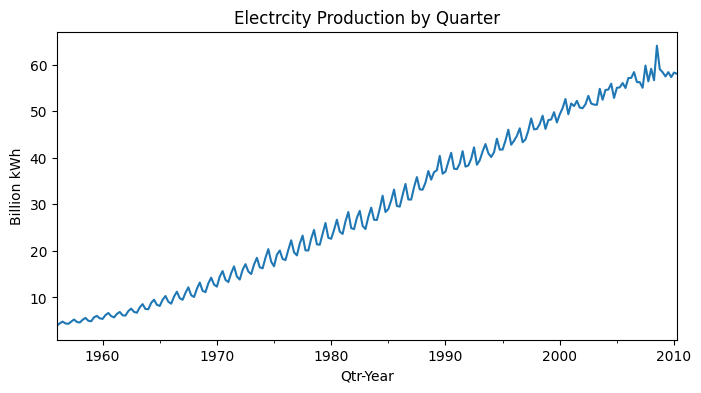

In [5]:
#| fig-align: center
qau = pd.read_csv('data/qauselec.csv', parse_dates=[0])
qau.set_index('date', inplace=True)
qau.index.freq = 'QS'

qau.plot(figsize=(8,4), title='Electrcity Production by Quarter', legend=False)
plt.xlabel('Qtr-Year'); plt.ylabel('Billion kWh');

There is a strong increasing trend. There is strong seasonality, and there is
no evidence of cyclic behaviour.

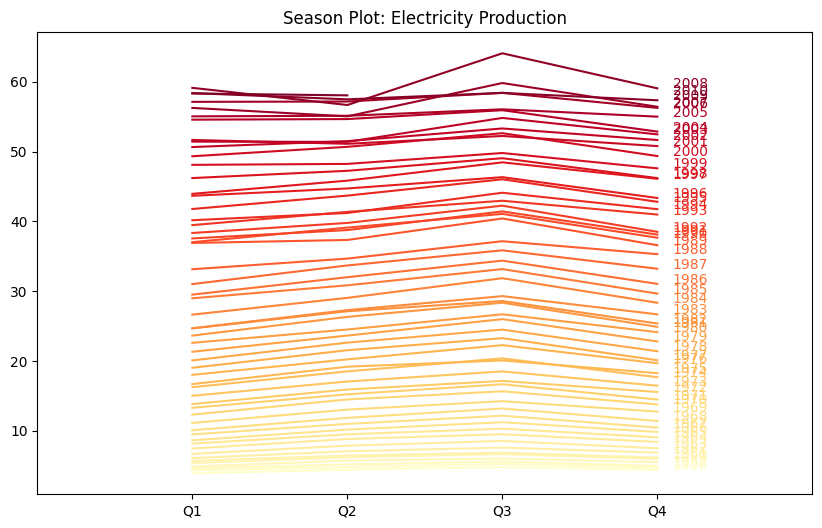

In [6]:
#| fig-align: center
#| fig-cap: "Season plot, electric production"
#| label: fig-season-qauselec

qau2 = qau.copy()

qau2.loc[:, 'year'] = qau2.index.year
qau2.loc[:, 'qtr'] = qau2.index.quarter
yrs = np.sort(qau2.year.unique())
color_ids = np.linspace(0, 1, num=len(yrs))
colors_to_use = plt.cm.YlOrRd(color_ids)

plt.figure(figsize=(10, 6))

for i,yr in enumerate(yrs):
    df_tmp = qau2.loc[qau2.year == yr, :]
    plt.plot(df_tmp.qtr, df_tmp.kWh, color=colors_to_use[i]);
    plt.text(4.1, df_tmp.kWh.iloc[-1], str(yr), color=colors_to_use[i])
plt.title('Season Plot: Electricity Production')
plt.xlim(0, 5)
plt.xticks(np.arange(1, 5), ['Q1', 'Q2', 'Q3', 'Q4']);

:::

<br/>

Most time series models are autoregressive in nature. This means that they
attempt to predict future observations based on previous ones. The observations
from the past could be from the time series that we are interested in, or they
could be from other time series that we believe are related.

When beginning with model fitting, we would want to have some idea about the
extent to which past observations affect the current one. In other words, how
many of the past observations should we include when forecasting new
observations? Lag plots and autocorrelation functions (acf) are the tools that
we use to answer this question.

If we denote the observation of a time series as $y_t$, then a lag plot at lag
$k, k > 0$ is a scatter plot of $y_t$ against $y_{t-k}$. It allows us to
visually assess if the observations that are $k$ units of time apart are
associated with one another. We typically plot several lags at once to observe
this relationship.

::: {#exm-housing-3 style="background-color: #D5D1D164; padding: 20px"}
### Lag plots of housing sales data
\index{Housing Sales!Lag Plots}

Here is a matrix of lag plots for the housing sales data.

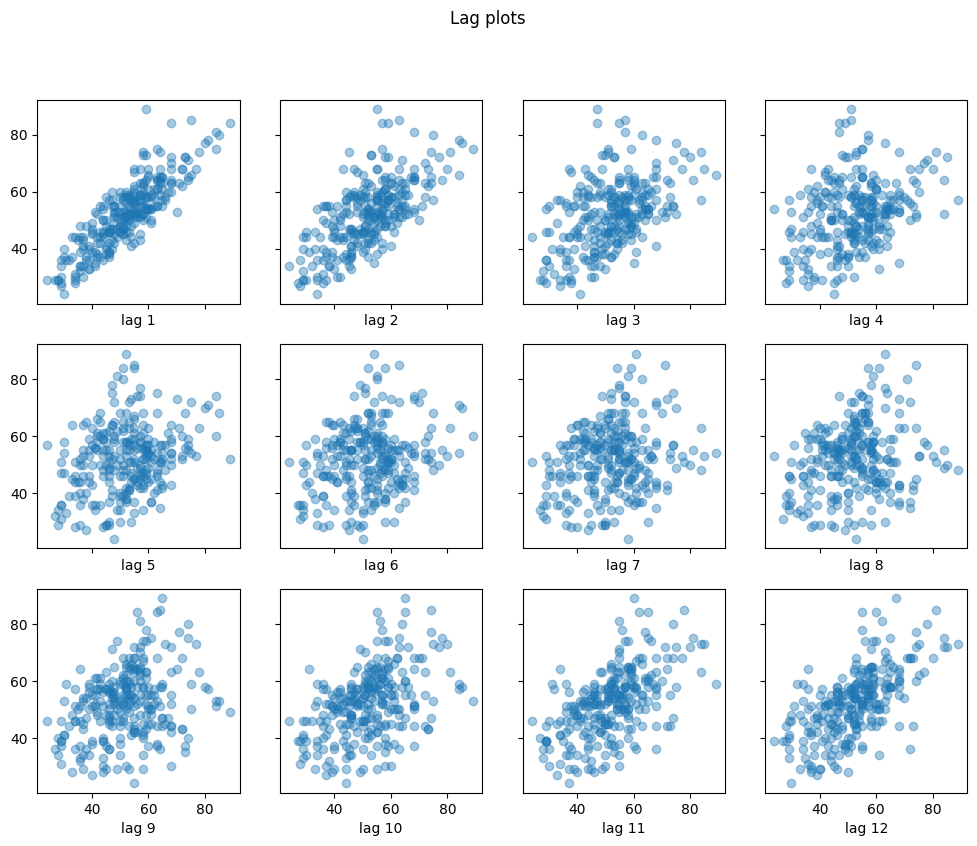

In [7]:
#| fig-align: center
f, aa = plt.subplots(nrows=3,ncols=4, sharex=True, sharey=True)
f.set_figheight(9)
f.set_figwidth(12)

y = hsales.hsales.values
for i in np.arange(0, 3):
    for j in np.arange(0, 4):
        lag = i*4 + j + 1
        aa[i,j].scatter(y[:-lag], y[lag:], alpha=0.4)
        aa[i,j].set_xlabel("lag " + str(lag))
f.suptitle('Lag plots');

:::

## Decomposing Time Series Data

In this section, our goal is still primarily exploratory, but it will also
return information that we can use to model our data later on. We aim to break
the time series readings into:

* a trend-cycle component,
* a seasonal component, and
* a remainder component.

If we can forecast these components individually, we can combine them to provide
forecasts for the original series (see @sec-06-fc-decomp). There are two basic
methods of decomposition into the above components: an additive one, and a
multiplicative one. In the additive decomposition, we assume that the components
contribute in an additive manner to $y_t$:

\begin{equation}
y_t = S_t + T_t + R_t
\end{equation}

In the multiplicative decomposition, we assume the following relationship holds:
\begin{equation}
y_t = S_t \times T_t \times R_t
\end{equation}

When we are in the multiplicative case, we sometimes apply the logarithm
transform to the data, which returns to an additive model:
\begin{equation}
\log y_t = \log S_t + \log T_t + \log R_t
\end{equation}

A typical algorithm to decompose time series data would work like this:

1. Estimate the trend component. Let us call it $\hat{T}_t$.
2. Obtain the de-trended data $y_t - \hat{T}_t$ or $y_t / \hat{T}_t$ as appropriate.
3. Estimate the seasonal component. For instance, we could simply average the values in each month. 
Let us denote this estimate as $\hat{S}_t$.
4. Estimate the remainder component. For instance, in the additive model, it would be 
$\hat{R}_t = y_t - \hat{T}_t - \hat{S}_t$.

::: {#exm-housing-3 style="background-color: #D5D1D164; padding: 20px"}
### Additive decomposition, housing sales
\index{Housing Sales!Additive Decomposition}

Here is the naive additive decomposition of the housing sales data.

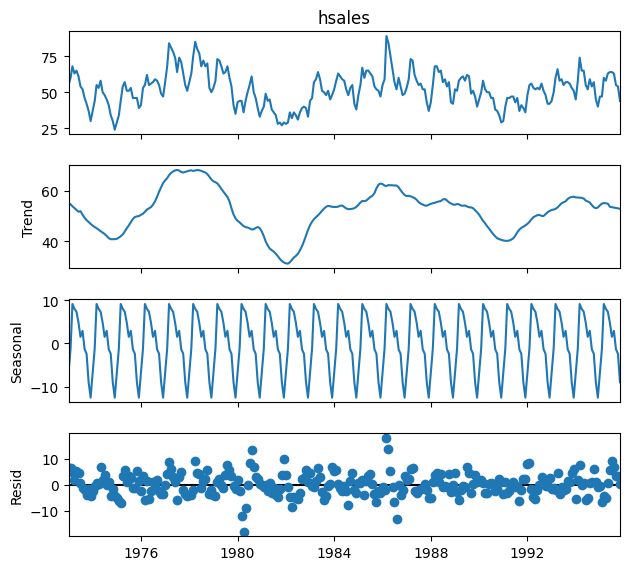

In [8]:
#| fig-align: center
#| fig-cap: "Additive decomposition"
#| label: fig-add-decomp-hsales
hsales_add = seasonal_decompose(hsales.loc[:, 'hsales'], 
                                model='additive', extrapolate_trend='freq')
ax = hsales_add.plot()
ax.set_figheight(6)

:::

When we inspect a decomposition, there are certain elements that we watch out
for. One of them is to compare the range of the $y$-axis for the three
components. In @fig-add-decomp-hsales, we observe that the rough spread of the
trend component (second row) is about 40. On the other hand, the spread of the
seasonal component (third row) is roughly 20. This suggests that the seasonal
component is a significant driver of the overall variation of the process.

The fact that the seasonal pattern does not change over time is an artifact of the 
decomposition; it is not always a true reflection of the true pattern. 

Finally, as always, we hope to see the residuals to be centred around 0, with 
little or no trend, and a constant variability over time.

::: {#exm-aus-elec-2 style="background-color: #D5D1D164; padding: 20px"}
### Multiplicative decomposition, Aus electricity data
\index{Australian QEC!Multiplicative Decomposition}

Here is the *multiplicative decomposition* for the Australian electric data.

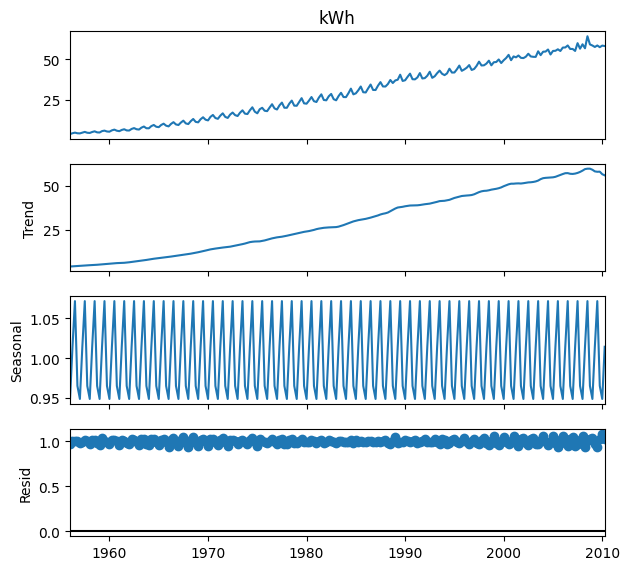

In [9]:
#| fig-align: center
qau_mult = seasonal_decompose(qau.loc[:, 'kWh'], model='multiplicative',
                              extrapolate_trend='freq')
ax = qau_mult.plot();
ax.set_figheight(6)

Take note that in multiplicative decompositions, the residuals are centred around 
1, not zero.

:::

As you may have noticed, there are some issues with the classical seasonal decomposition algorithms. These include:

* an inability to estimate the trend at the ends of the series.
* an inability to account for changing seasonal components.
* it is not robust to outliers.

::: {#exm-aus-elec-3 style="background-color: #D5D1D164; padding: 20px"}
### STL decomposition, Aus electricity
\index{Australian QEC!STL Decomposition}

Newer algorithms such as STL decomposition, X11 and others attempt to address
these issues. They use locally weighted regression models to obtain the trend.
These algorithms iterate over the time series several times, so as to ensure
that outliers are not affecting the outcome. For full details on STL (Seasonal
Trend decomposition with Loess), please refer to the original paper @cleveland1990stl.

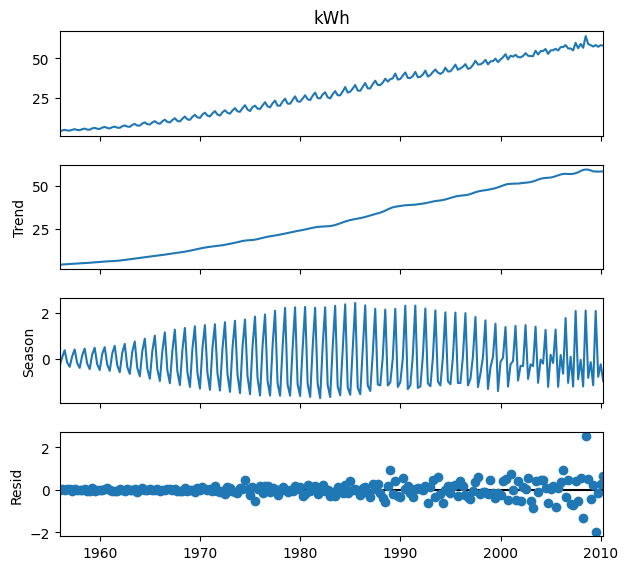

In [10]:
#| fig-align: center
#| fig-cap: "STL decomposition, electricity data"
#| label: fig-stl-decomp
qau_stl = STL(qau.kWh).fit()
ax = qau_stl.plot();
ax.set_figheight(6)

Notice in @fig-stl-decomp how the seasonal pattern varies over time. One
disadvantage of the STL decomposition, however, is that it can only return an
additive decomposition.

:::

## Forecasting

### Benchmark methods

As in all forecasting methods, it is useful to obtain a baseline forecast
before proceeding to more sophisticated techniques. Baseline forecasts are
usually obtained from simple, intuitive methods.

::: {.callout-note}
Take note in the sections that follow, the notation $\hat{y}_{T+h|T}$ refers to 
the forecasted value of the time series at time $T+h$, given observations until
and including time $T$.
:::

Here are some baseline methods:

A. The simple mean forecast:  
\begin{equation}
\hat{y}_{T+h | T} = \frac{y_1 + y_2 + y_3 + \cdots + y_T}{T}
\end{equation}

B. The naive forecast:
\begin{equation}
\hat{y}_{T+h | T} = y_T
\end{equation}

C. The seasonal naive forecast.

Suppose that the season contains $d$ periods (for instance, in monthly data,
$d=12$). Then the seasonal naive forecast utilises the most recent observed
period for the forecast:

\begin{equation}
\hat{y}_{T+h | T} = y_{T-d+h}
\end{equation}


::: {#exm-housing-4 style="background-color: #D5D1D164; padding: 20px"}
### Benchmark forecasts housing sales
\index{Housing Sales!Benchmark Forecasts}

Suppose we apply some of the above forecasts to the housing sales dataset. We
withhold the most recent 2 years of data and forecast those. Here is a plot
depicting the forecasts, and the true values.


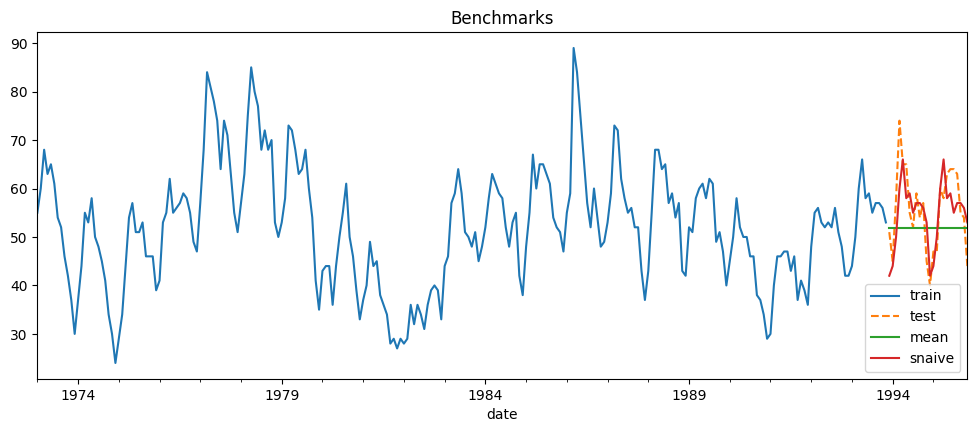

In [11]:
#| fig-align: center
#| fig-cap: "Benchmark forecasts"

# Set aside the last two years as the test set.
#hsales = hsales.drop(columns=['year', 'month'])
train_set = hsales.iloc[:-24,]
test_set = hsales.iloc[-24:, ]

# Obtain the forecast from the training set
mean_forecast = ts.meanf(train_set.hsales, 24)
snaive_forecast = ts.snaive(train_set.hsales, 24, 12)

# Plot the predictions and true values
ax = train_set.hsales.plot(title='Benchmarks', legend=False, figsize=(12,4.5))
test_set.hsales.plot(ax=ax, legend=False, style='--')
mean_forecast.plot(ax=ax, legend=True, style='-')
snaive_forecast.plot(ax=ax, legend=False, style='-')
plt.legend(labels=['train', 'test', 'mean', 'snaive'], loc='lower right');

:::

When assessing forecasts, there are a few different metrics that are typically
applied. Each of them has it's own set of pros and cons. If we denote the
predicted value with $\hat{y}_t$, then these are the formulas for three of the
most common error metrics used in time series forecasting

A. RMSE: 
\begin{equation}
\sqrt{\frac{1}{h} \sum_{i=1}^h (y_{t+i} - \hat{y}_{t+i})^2 }
\end{equation}

B. MAE
\begin{equation}
\frac{1}{h} \sum_{i=1}^h |y_{t+i} - \hat{y}_{t+i}|
\end{equation}
    
C. Mean Absolute Scaled Error

\begin{equation}
\frac{1}{h} \sum_{i=1}^h \frac{|y_{t+i} - \hat{y}_{t+i}|}{ \frac{1}{T-1} \sum_{t=2}^T |y_t - y_{t-1}|}
\end{equation}

The RMSE and MAE are scale dependent errors. It is difficult to compare the
errors across series, or to aggregate errors across different time series with
it. Due to the square in the formula, the RMSE is quite sensitive to outliers.
The MAE is more robust to outliers. 

The MASE is a scaled error - it allows us to compare the forecasting performance
*across* time series. The other two metrics depend on the scale of the time
series and hence do not allow us to make such comparisons.

::: {#exm-housing-4a style="background-color: #D5D1D164; padding: 20px"}
### Benchmark forecast errors
\index{Housing Sales!Benchmark forecast errors}

Let us assess the forecasts made in the previous example, using RMSE and MAE.

In [12]:
for x in [ts.rmse, ts.mae]:
    print(f"{x.__name__},mean: {x(test_set.hsales.values, mean_forecast.values):.3f}")
    print(f"{x.__name__},snaive: {x(test_set.hsales.values, snaive_forecast.values):.3f}")
    print('---')

rmse,mean: 9.023
rmse,snaive: 5.906
---
mae,mean: 7.562
mae,snaive: 4.792
---


In our simple example, the seasonal naive model outperforms the simple mean
forecast according to all the metrics but in general, things are not always this
clear-cut.

:::

For reference, the MASE for the seasonal naive forecast is as follows.

In [13]:
ts.mase(test_set.hsales.values,  snaive_forecast.values, train_set.values, 
        seasonality=12)

np.float64(1.5154940449933834)

### ARIMA Models

Now let us turn to a huge class of models that have been utilised in time series
forecasting since the 1960's. They are known as ARIMA models. ARIMA stands for
AutoRegressive Integrated Moving Average models. These models are appropriate
for **stationary** processes. Stationarity is a technical term that refers to
processes

* that have a constant mean. This means that the process merely fluctuates about 
  a fixed level over time.
* whose covariance function does not change over time. This means that, for a 
  fixed $h$, the covariance between $y_t$ and $y_{t+h}$ is the same for all $t$.
* whose variance is constant over time.

How can we tell if a process is stationary or not? The following time series is
not stationary. Why?

::: {#exm-dow-1 style="background-color: #D5D1D164; padding: 20px"}
### Dow Jones index
\index{Dow Jones!Differencing}

Consider the following time series of the Dow Jones index.

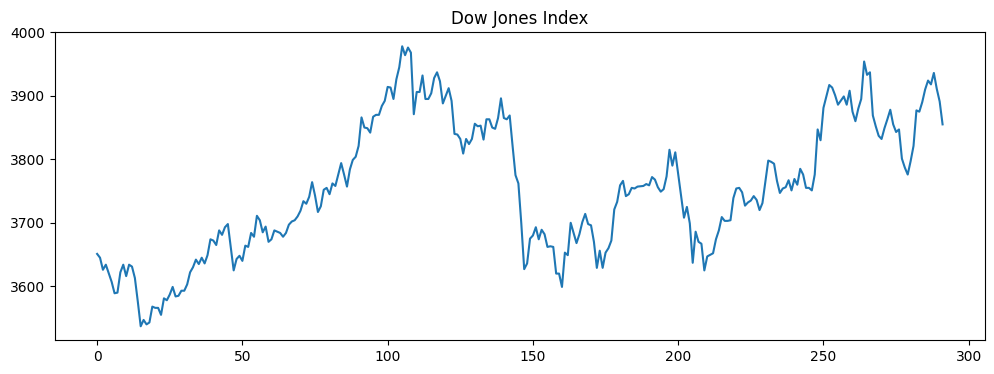

In [14]:
#| fig-align: center
dj = pd.read_csv('data/dj.csv')
dj.plot(legend=False, title='Dow Jones Index', figsize=(12,4));

It is nonstationary because the mean (level) of the time series is not constant.
However, the following differenced version of the same series is:

\begin{equation}
\Delta y_t = y_t - y_{t-1}
\end{equation}

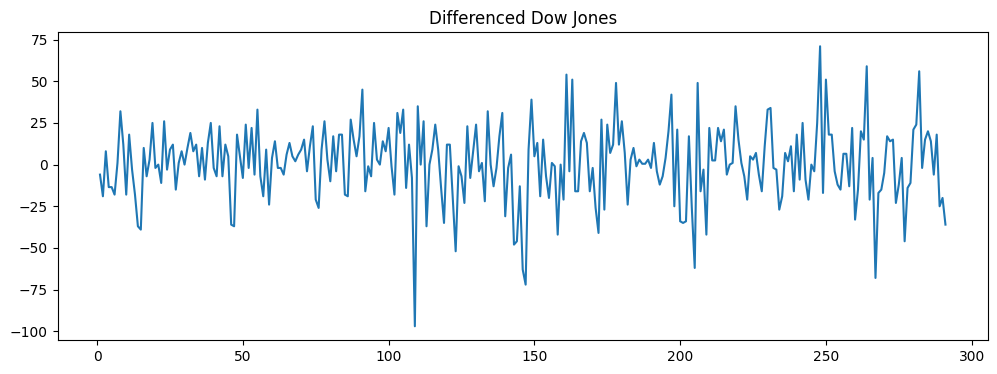

In [15]:
#| fig-align: center
ddj = diff(dj)
ddj.plot(legend=False, title='Differenced Dow Jones', figsize=(12,4));

:::

ARIMA models revolve around the idea that if we have a non-stationary series,
we can transform it into a stationary one with a suitable number of
differencing. A more general way of studying if a series is stationary is to
plot it's AutoCorrelation Function (ACF). The ARIMA method directly models the
ACF. That is why it is so important for this class of models. The ACF of a
stationary process should "die down" quickly. @fig-acf-diff shows the ACF of the
Dow Jones data, before and after differencing.

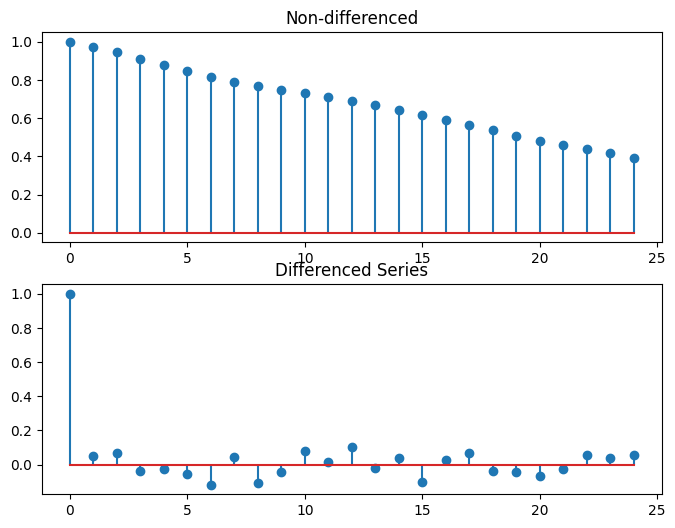

In [16]:
#| fig-align: center
#| fig-cap: "ACF, before and after differencing"
#| label: fig-acf-diff
 
plt.figure(figsize=(8, 6))
plt.subplot(211)
plt.stem(acf(dj, fft=False))
plt.title("Non-differenced")
plt.subplot(212)
plt.stem(acf(ddj, fft=False));
plt.title("Differenced Series");

Now suppose that, starting from our original series $y_t$, we difference it a
sufficient number of times and obtain a stationary series. Let's call this
$y'_t$. The ARIMA model assumes that 

\begin{equation}
y'_t = c + \phi_1 y'_{t-1} + \phi_2 y'_{t-2} + \cdots + \phi_p y'_{t-p} + \theta_1 e_{t-1} + \cdots + \theta_q e_{t-q}
\end{equation}

* The $e_j$ correspond to unobserved innovations. They are typically assumed to
  be independent across time with a common variance.
* The $\phi$ and $\theta$ terms are unknown coefficients to be estimated.
* If $y'_t$ was obtained by performing $d$ successive differencings, then the
  above ARIMA model is referred to as an $\text{ARIMA}(p,d,q)$ model.

In olden days, the $p$, $d$ and $q$ parameters were picked by the analyst after
inspecting the ACF, PACF, and time plots of the differenced series. Today, we
can iterate through a large number of them and pick the best according to a
well-established criteria (AIC).

::: {#exm-aus-elec-4 style="background-color: #D5D1D164; padding: 20px"}
### Auto ARIMA on Aus electricity
\index{Australian QEC!Auto ARIMA}

Let us try out the ARIMA auto-fitting algorithm on the qau electricity usage
dataset. We shall set aside the last three years of data as the test set.
Recall that this is quarterly data. First, we establish the seasonal naive
benchmark error for this dataset.

In [17]:
train2 = qau.kWh[:-12]
test2 = qau.kWh[-12:]

snaive_f = ts.snaive(train2, 12, 4)
print(f"The RMSE is approximately {ts.rmse(test2.values, snaive_f.values):.3f}.")

The RMSE is approximately 2.545.


Let us see if the automatically fitted ARIMA models can do better than this.

In [18]:
#| echo: false
import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*'force_all_finite' was renamed to 'ensure_all_finite'.*",
    category=FutureWarning,
)
arima_m1 = pm.auto_arima(train2.values, seasonal=True, m=4, test='adf', 
                         trace=False, suppress_warnings=True)

In [19]:
#| eval: false
arima_m1 = pm.auto_arima(train2.values, seasonal=True, m=4, test='adf', 
                         trace=False, suppress_warnings=True)

Here is the summary of the final chosen model.

In [20]:
print(arima_m1.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  206
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 4)   Log Likelihood                -175.200
Date:                             Sun, 24 May 2026   AIC                            364.400
Time:                                     16:51:45   BIC                            387.661
Sample:                                          0   HQIC                           373.809
                                             - 206                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3584      0.254     -1.412      0.158      -0.856       0.139
ar.L2          0.4194      

The output indicates that a seasonal ARIMA model has been found to be the best 
one. The column `coef` contains estimates of the parameters in the model. The 
section below contains information on statistical tests 

- for Normality on the residuals (Ljung-Box and Jarque-Bera), and
- for constant variance.

In addition to tests, we should always create plots to assess the validity of 
residuals.

:::

Once we have found the best-fitting model, we do what we do with any other model
in data analytics: we have to inspect the residuals. The residuals should look
like trash to us - there should be no clues about the data in them. With
reference to @fig-arima-diag, the standardized residual in the top left should
be consistently wide; it isn't. In fact this information is also reflected in
the model output summary (see `Heteroskedasticity (H)`). This suggests some sort
of transformation of the data before modeling might be appropriate.

The two plots on the off-diagonal are meant for us to assess if the residuals
are Normally distributed with mean 0. They do indeed look like it.

The final plot, in the bottom right, displays an ACF with no spikes, indicating
that the residuals are uncorrelated. This is precisely what we wished to see.

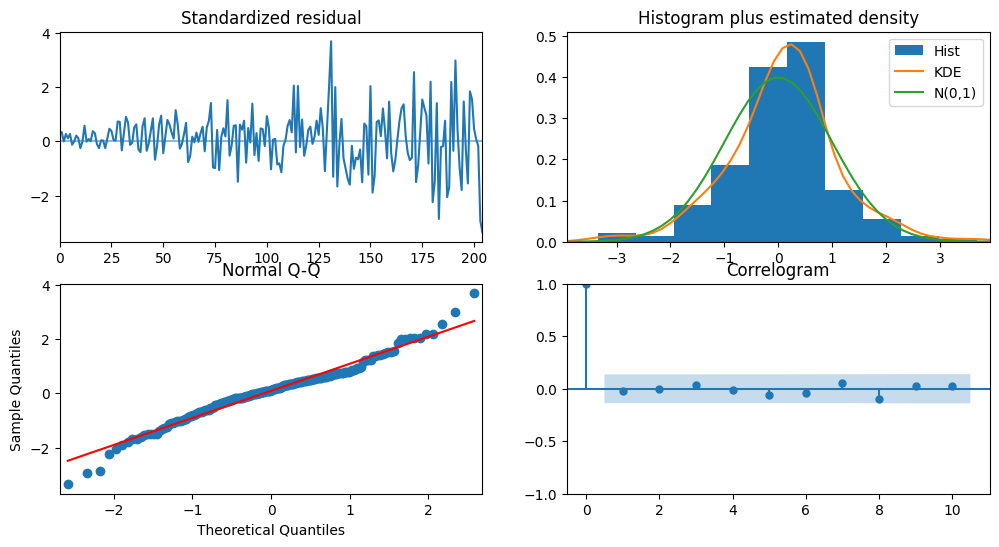

In [21]:
#| fig-align: center
#| fig-cap: "ARIMA residual diagnostics"
#| label: fig-arima-diag
arima_m1.plot_diagnostics(figsize=(12,6));

Finally, we assess the error on the test set. The out-of-sample performance is
better than the naive methods. 

In [22]:
rmse1 = ts.rmse(test2.values, arima_m1.predict(n_periods=12))
mase1 = ts.mase(test2.values, arima_m1.predict(n_periods=12), 
                train2.values, seasonality=4)
print(f"The RMSE on the test set is {rmse1:.3f}.")
print(f"The MASE on the test set is {mase1:.3f}.") 

The RMSE on the test set is 1.943.
The MASE on the test set is 1.235.


Let us proceed to make a plot of the predictions.

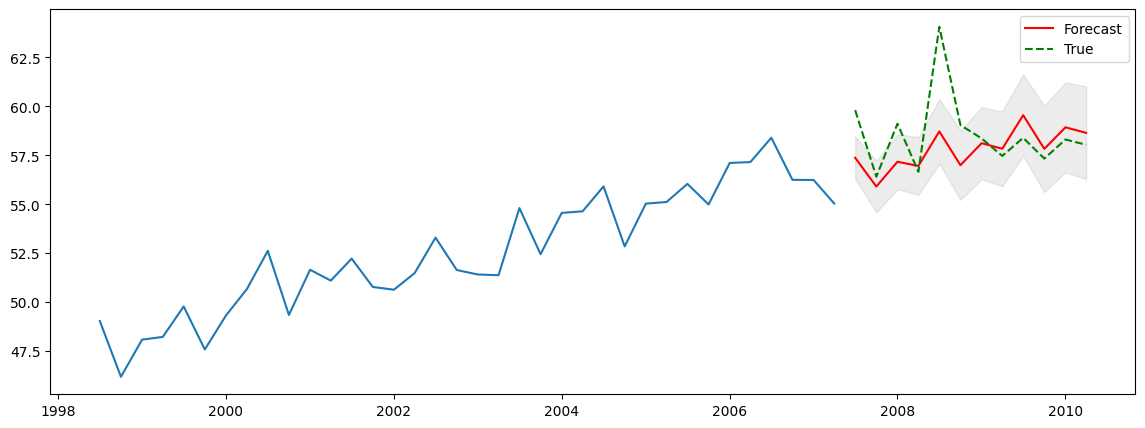

In [23]:
#| fig-align: center
#| label: fig-arima-fc
#| fig-cap: "ARIMA forecasts"
n_periods = 12
fc, confint = arima_m1.predict(n_periods=n_periods, return_conf_int=True)

ff = pd.Series(fc, index=test2.index)
lower_series = pd.Series(confint[:, 0], index=test2.index)
upper_series = pd.Series(confint[:, 1], index=test2.index)

plt.figure(figsize=(14, 5))
plt.plot(train2[-36:])
plt.plot(ff, color='red', label='Forecast')
plt.fill_between(lower_series.index, lower_series, upper_series, color='gray', alpha=.15)
plt.plot(test2, 'g--', label='True')
plt.legend();

### ETS 

ETS models are a new class of models, that define a time series process
according to a set of state space equations:

\begin{eqnarray}
y_t &=& w' x_{t-1} + e_t \\
x_t &=& F x_{t-1} + g e_t
\end{eqnarray}

The unobserved **state** $x_t$ is usually a vector, and it typically contains
information about

* the level of the process at time $t$.
* the seasonal effect at time $t$
* the trend or growth factor at time $t$.

All these parameters are updated at every point in time. For instance, the
simplest ETS model (A,N,N), is one that assumes that there is only a level
parameter, and that it is updated as a weighted average of the most recent
levels:

\begin{eqnarray}
l_t &=& \alpha y_t + (1- \alpha)l_{t-1} \\
\hat{y}_{t+1} &=& l_t
\end{eqnarray}

The definition of the model is very flexible, and allows multiplicative growth,
linear growth and damped terms in the model. All this, in addition to not
requiring the assumption of stationarity!

@fig-ets-add-models contains a full table of the additive models, while
@fig-ets-mult-models contains the multiplicative models. They were taken from
@hyndman2018forecasting.

::: {layout-ncol=1}

![](figs/ets_add.png){#fig-ets-add-models width=80%}

![](figs/ets_mult.png){#fig-ets-mult-models width=80%}

:::

\pagebreak

::: {#exm-aus-elec-5 style="background-color: #D5D1D164; padding: 20px"}
### ETS model on Aus electricity dataset 
\index{Australian QEC!ETS Model}

Let us try one of the basic models, with just a slope, level and seasonal
effect ETS(A,A,A), on the qau dataset.

In [24]:
ets_m1 = ExponentialSmoothing(train2.values, seasonal_periods=4, trend='add', 
                              seasonal='add')
ets_fit = ets_m1.fit()
print(ets_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    endog   No. Observations:                  206
Model:             ExponentialSmoothing   SSE                             64.907
Optimized:                         True   AIC                           -221.915
Trend:                         Additive   BIC                           -195.292
Seasonal:                      Additive   AICC                          -220.787
Seasonal Periods:                     4   Date:                 Sun, 24 May 2026
Box-Cox:                          False   Time:                         16:52:04
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.6206188                alpha                 True
smoothing_trend          

The plots in @fig-ets-components plot the estimated trend and level for the
series. Notice how there is an almost constant slope for the series.

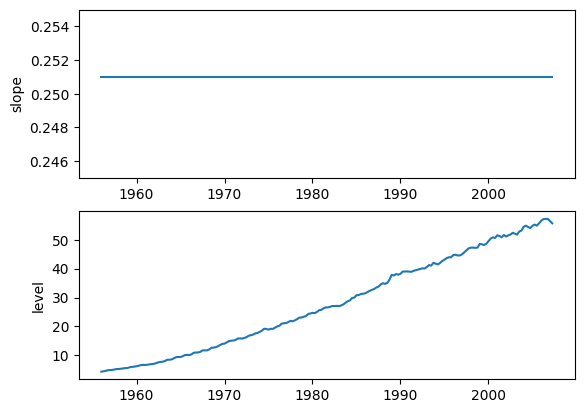

In [25]:
#| fig-align: center
#| fig-cap: ETS trend and level components
#| label: fig-ets-components
plt.subplot(211)
plt.plot(train2.index, ets_fit.trend, scaley=False)
plt.ylim(0.245, 0.255)
plt.ylabel('slope')

plt.subplot(212)
plt.plot(train2.index, ets_fit.level)
plt.ylabel('level');

Finally, let's take a look if the predictions on the test set are competitive
with the automatic ARIMA model that was selected earlier. The forecasts are
better than the naive ones, but not as good as the ARIMA. However, keep in mind
that we are working with a single model - just as we did for ARIMA models, we
should iterate over several ETS models and pick the best one in order to compare
with the ARIMA model found.

In [26]:
ets_fc = ets_fit.forecast(steps=12)
print(f"The RMSE on the test set is {ts.rmse(test2.values, ets_fc):.3f}.")

The RMSE on the test set is 2.237.


:::

### Theta Method

The Theta method is a forecasting approach that has proved to be quite
effective in competitions. It regularly appears as one of the best-performing
models.  Instead of decomposing a time series into Trend, Season and Remainder
terms, the theta method decomposes a *seasonally adjusted* time series into
**short-** and **long-term** components. The full reference for this method is
@assimakopoulos2000theta.

Suppose we are interested in forecasting a time series $\{y_t\}$. The theta
decomposition is based on the concept of amplifying/diminishing the local
curvatures of the time series. This is brought about through a coefficient
$\theta$; hence the name of the model.

As a preview, we are going to find series $\{ x_{\theta,t}\}$ and 
$\{ x_{1 - \theta,t}\}$ such that

$$
y_t = \frac{1}{2}(x_{\theta,t} + x_{1 - \theta,t})
$$

In order to forecast $y_t$, we shall forecast $\{ x_{\theta,t}\}$ and $\{ x_{1
- \theta,t}\}$ separately and then combine them. There are numerous possible
pairs of $\{ x_{\theta,t}\}$ and $\{ x_{1 - \theta,t}\}$ that we can use.
However the most common one is where $x_\theta$ corresponds to a straight line
OLS fit, and $x_{1 - \theta}$ corresponds to a version of the time series with
its curvature amplified.

::: {#exm-tourism-1 style="background-color: #D5D1D164; padding: 20px"}
### International tourism arrivals to Singapore
\index{Singapore tourist numbers!Basic plot}

The Singapore Department of Statistics shares information on tourist arrivals
to Singapore at the monthly level. Here is a time series plot of arrivals from
South East Asian Countries:

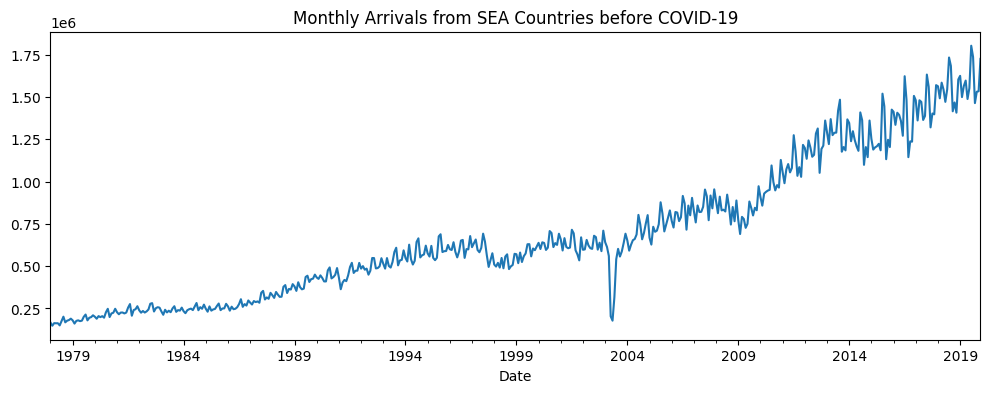

In [28]:
#| fig-align: center
tourism = pd.read_excel("data/international_visitor_arrivals_sg.xlsx", 
                        parse_dates=[0], date_format="%Y %b", 
                        na_values='na')
sea_tourism = tourism.iloc[:, 0:9]
sea_tourism.columns = ['Date', 'SEA', 'Brunei', 'Indonesia' ,'Malaysia', 
                       'Myanmar', 'Philippines', 'Thailand', 'Vietnam']
sea_tourism.Date = sea_tourism.Date.str.replace('  ', '')
sea_tourism.Date = pd.to_datetime(sea_tourism.Date, format="%Y %b")
sea_tourism.set_index('Date', inplace=True)
sea_tourism.sort_index(inplace=True)
sea_tourism.index.freq = 'MS'

sea2 = sea_tourism.SEA[sea_tourism.index < datetime.datetime(2020, 1, 1)]
fig = sea2.plot(figsize=(12,4));
fig.set_title('Monthly Arrivals from SEA Countries before COVID-19');

The data was obtained from the 
[Department of Statistics](https://www.singstat.gov.sg/). Take note that we are
only going to focus on pre-COVID data.

:::

<br>

To fit the theta model for this dataset, we use the following code:

In [29]:
theta_mod = ThetaModel(sea2)
theta_mod_fit = theta_mod.fit()
print(theta_mod_fit.summary())

                              ThetaModel Results                              
Dep. Variable:                    SEA   No. Observations:                  504
Method:                       OLS/SES   Deseasonalized:                   True
Date:                Sun, 24 May 2026   Deseas. Method:         Multiplicative
Time:                        16:52:42   Period:                             12
Sample:                    01-01-1978                                         
                         - 12-01-2019                                         
  Parameter Estimates   
          Parameters    
------------------------
b0    2628.8595906871597
alpha 0.8383848338839772
------------------------


Here is what the two components from the model look like, in comparison to the
seasonally adjusted series (based on a multiplicative decomposition).

::: {.callout-note}

The calculations in the next cell are based on formulas for the theta
decomposition that we won't get into. They are just for illustration of how the
decomposition is in terms of long and short term trends, rather than the
cross-sectional decompositions we have been dealing with so far. The orange dashed 
line in @fig-theta-decomp denotes the long-term trend that the model has identified,
while the green dashed line denotes the short-term trend. The blue solid line is the 
seasonally adjusted time series.

:::

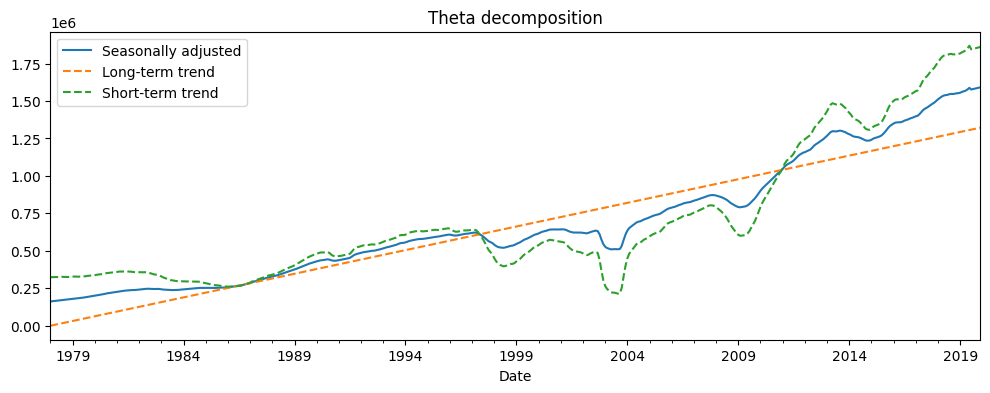

In [30]:
#| fig-align: center
#| fig-cap: "Theta decomposition"
#| label: fig-theta-decomp
#| 
# carry out mutliplicative decomposition in order to obtain seasonally adjusted series
sea2_mult = seasonal_decompose(sea2, model='multiplicative', extrapolate_trend='freq')

# get long-term trend slope and intercept
a0 = (sea2.mean() - theta_mod_fit.params['b0']*(503)/2)/1e6
xvals = np.arange(1, 505)
yvals1 = a0 + theta_mod_fit.params['b0']*(xvals - 1)
yvals1 = pd.Series(data=yvals1, index=sea2.index)

# get short term trend series
a2 = -1*a0
b2 = -1*theta_mod_fit.params['b0']
yvals2 = a2 + b2*(xvals - 1) + 2*(sea2_mult.resid + sea2_mult.trend)
yvals2 = pd.Series(data=yvals2, index=sea2.index)
fig = (sea2_mult.resid + sea2_mult.trend).plot(label='Seasonally adjusted', 
                                               legend=True, figsize=(12,4));
yvals1.plot(legend=True, label='Long-term trend', style="--")
yvals2.plot(legend=True, label='Short-term trend', style="--");
fig.set_title("Theta decomposition");

Finally, we visualise the forecasts from this theta decomposition model. We only 
plot the final 360 observations for the visualisation.

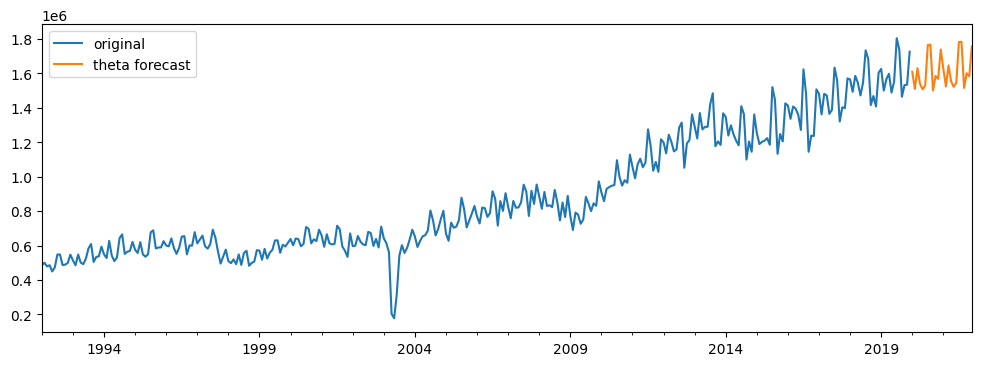

In [31]:
#| fig-align: center
theta_forecasts = pd.DataFrame(
    {
        "original": sea2,
        "theta forecast": theta_mod_fit.forecast(24)
    }
)
theta_forecasts.tail(360).plot(figsize=(12,4));

### Forecasting with Seasonal Decomposition {#sec-06-fc-decomp}

Continuing with the tourism data, we demonstrate how we can utilise a seasonal
decomposition (not theta decomposition) model to make forecasts. Recall that a
seasonal decomposition breaks the series down into the trend, seasonal and
residual components. Seasonal decompositions are typically used to *study* a
time series, but they can also be used to make forecasts. One approach is to
use either ARIMA or ETS to predict the seasonally adjusted component, and then
to use a seasonal naive model to predict the seasonal component. These two
forecasts will then be combined to create the final forecast.

::: {#exm-tourism-2 style="background-color: #D5D1D164; padding: 20px"}
### Tourism forecasts with decomposition
\index{Singapore tourist numbers!Forecast with decomposition}

Here is the code that will use and STL model to decompose the series, and fit a
pre-chosen ARIMA(3,1,2) model to the seasonally adjusted series.

/home/viknesh/NUS/coursesTaught/ind5003-book/env/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


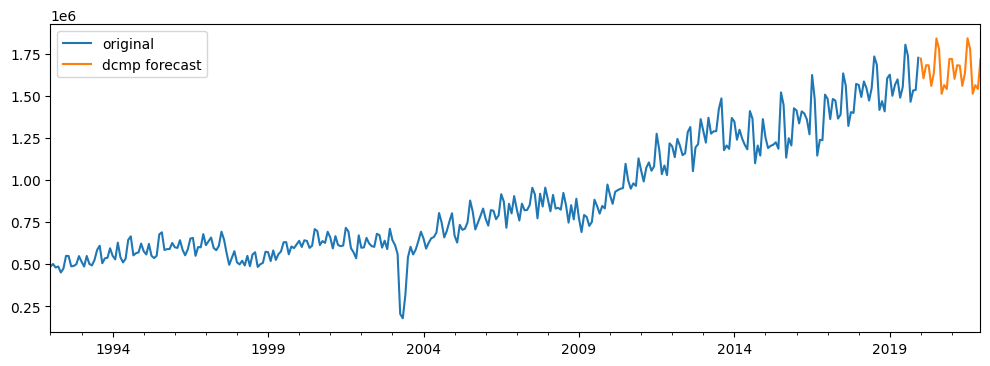

In [32]:
#| fig-align: center
stlf = STLForecast(sea2, ARIMA, model_kwargs={"order": (3, 1, 2)})
res = stlf.fit( )
forecasts2 = pd.DataFrame(
    {
        "original": sea2,
        "dcmp forecast": res.forecast(24)
    }
)
forecasts2.tail(360).plot(figsize=(12,4));

:::

## Miscellaneous Topics

### Time Series Clustering

::: {#exm-us-emp-1 style="background-color: #D5D1D164; padding: 20px"}
### Time series clustering, US employment data
\index{US Employment!Clustering}

The [Forecasting: Principles and Practice](https://otexts.com/fpp3/) contains
time series data on employment in various sectors in the US. There are 148
unique series in the dataset.

In [33]:
us_employment = pd.read_csv("data/us_employment.csv", parse_dates=[0], 
                            date_format="%Y %b")
series_ids = us_employment.Series_ID.unique()
us_employment.sample(n=8)

,Month,Series_ID,Title,Employed
32458,1979-02-01,CEU3133700001,Durable Goods: Furniture and Related Products,NaN
91480,1971-11-01,CEU5553100001,Financial Activities: Real Estate,NaN
23817,1985-10-01,CEU3133300001,Durable Goods: Machinery,NaN
58109,2017-03-01,CEU4244700001,Retail Trade: Gasoline Stations,920.1
100265,1977-03-01,CEU6054160001,Professional and Business Services: Management...,NaN
18785,1970-03-01,CEU3100000001,Durable Goods,11141.0
87670,1977-05-01,CEU5552211001,Financial Activities: Commercial Banking,NaN
54263,2019-09-01,CEU4244300001,Retail Trade: Electronics and Appliance Stores,457.6


Here is a plot of one of the time series in the dataset.

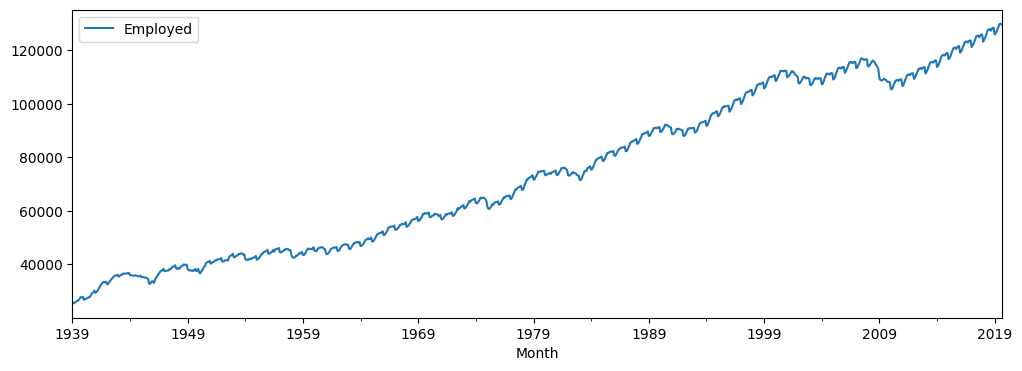

In [34]:
#| fig-align: center
us_employment[us_employment.Title == "Total Private"].plot(x='Month', 
                                                           y='Employed', 
                                                           figsize=(12,4));

Since we are going to perform clustering on the time series data, our first step
is to remove the missing values.

In [35]:
us_full = us_employment[(us_employment.Month >= datetime.datetime(2002, 9, 30)) & (us_employment.Month < datetime.datetime(2018, 1, 1) )   ]
us2 = us_full.pivot(index='Series_ID', columns='Month', values="Employed")
us2_array = us2.to_numpy()

Now we can begin the clustering procedure. The first line in the code below generates
a 148 x 148 distance matrix.

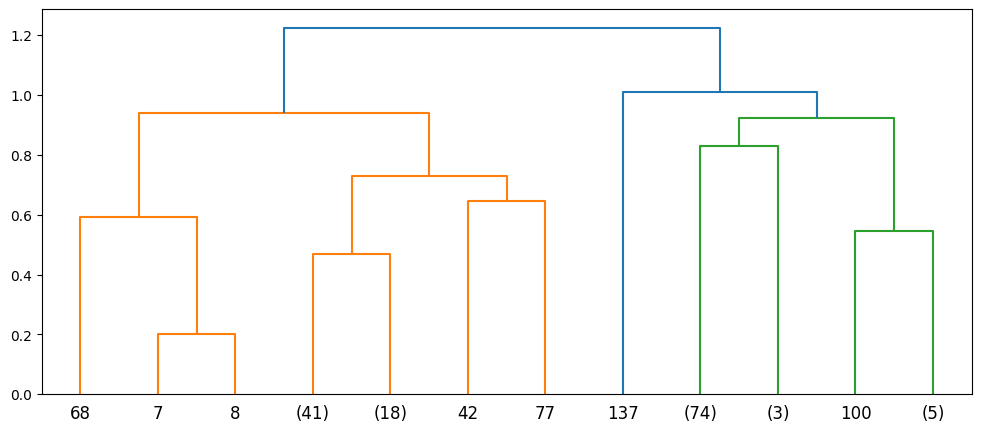

In [36]:
#| fig-align: center
out = pdist(us2_array, metric='correlation')
lm1 = hierarchy.linkage(out, method='average', optimal_ordering=True)

plt.figure(figsize=(12,5))
hierarchy.dendrogram(lm1, p=3, truncate_mode='level',color_threshold=True);

We reorder the columns and rows in the matrix so that similar time series appear
next to one another.

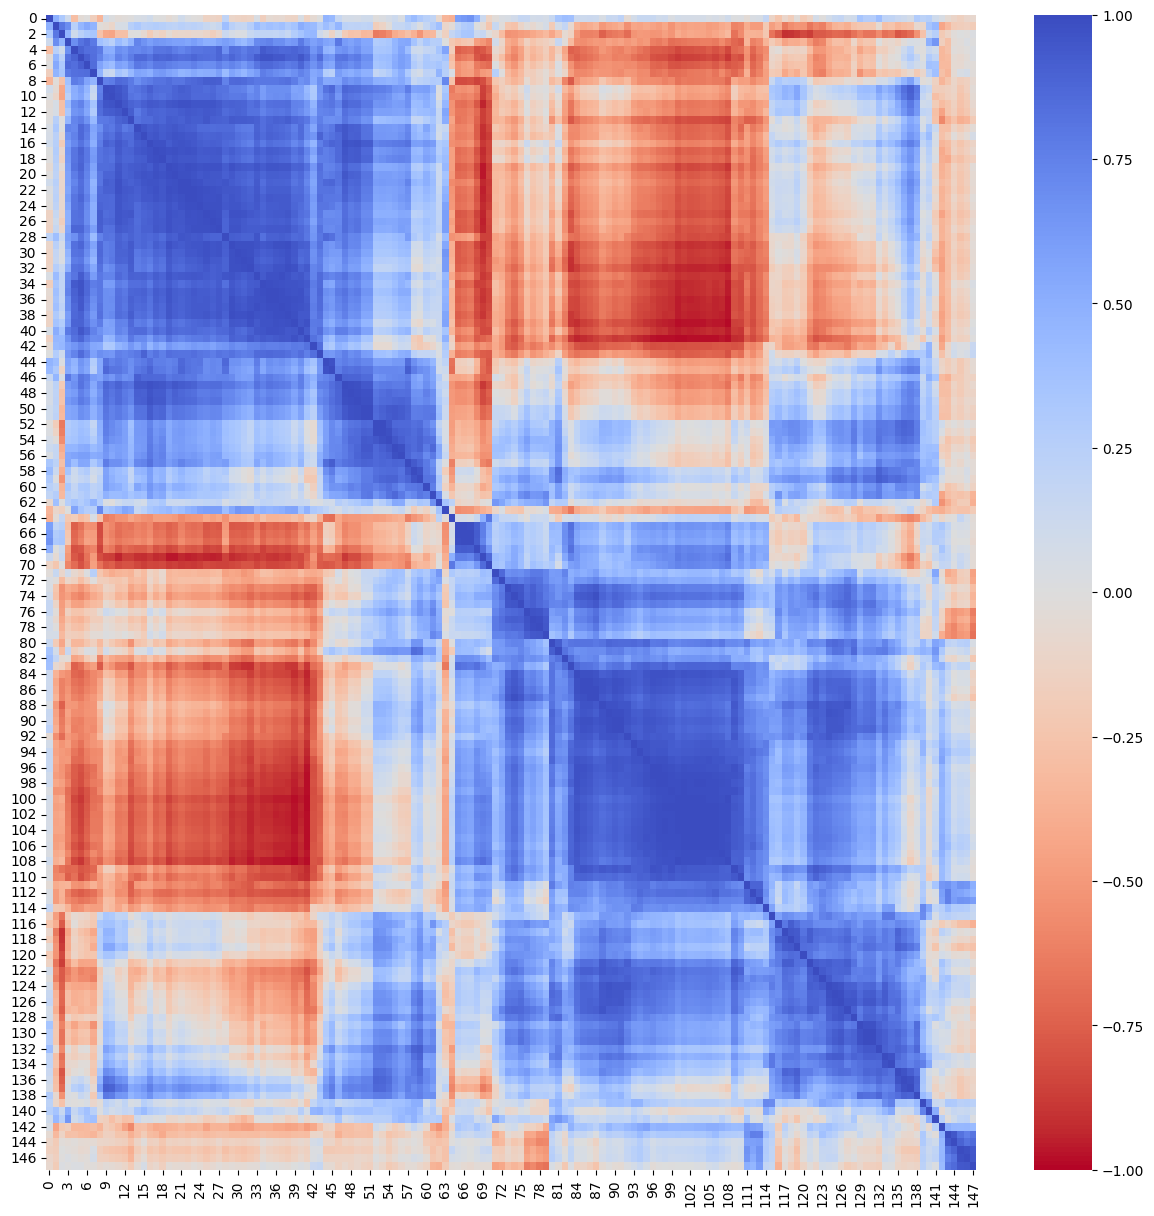

In [37]:
#| fig-align: center
#| label: fig-heatmap-correl
#| fig-cap: "Heatmap of correlation matrix"
 
X_ord = us2_array[hierarchy.leaves_list(lm1)]
corr_mat_ord = np.corrcoef(X_ord)
plt.figure(figsize=(15, 15))
sns.heatmap(corr_mat_ord, vmin=-1, vmax=1, cmap='coolwarm_r', center=0);

:::

In the next few plots, we use the heatmap in @fig-heatmap-correl to pick out
series that are close to one another. Series in blue segments of the matrix are 
highly correlated; here we inspect them to try to characterise the similarity.

The series in @fig-sim-1 seem to have a dip around the period 2009 - 2011, while
those in @fig-sim-2 have a cyclical pattern.

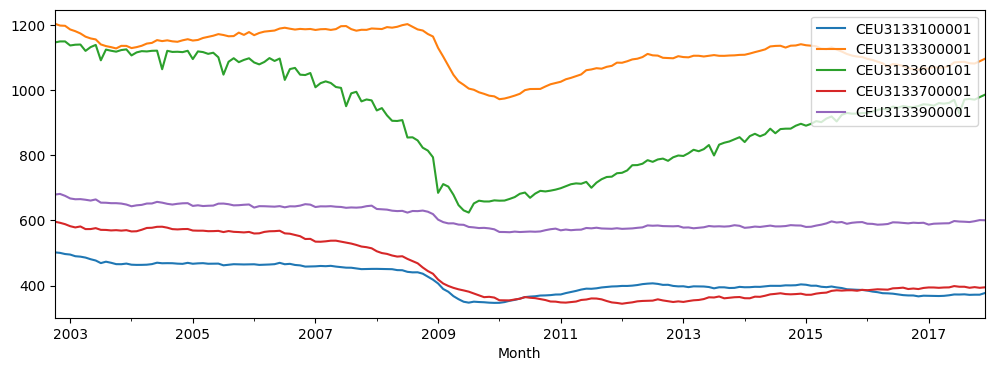

In [38]:
#| fig-align: center
#| label: fig-sim-1
#| fig-cap: Series from top left corner of heatmap
us2_series = us2.index.to_list()
ss = [us2_series[x] for x in [22, 24, 32, 33, 34]]
us2.T.loc[:, ss].plot(figsize=(12,4));
plt.legend(loc='upper right');

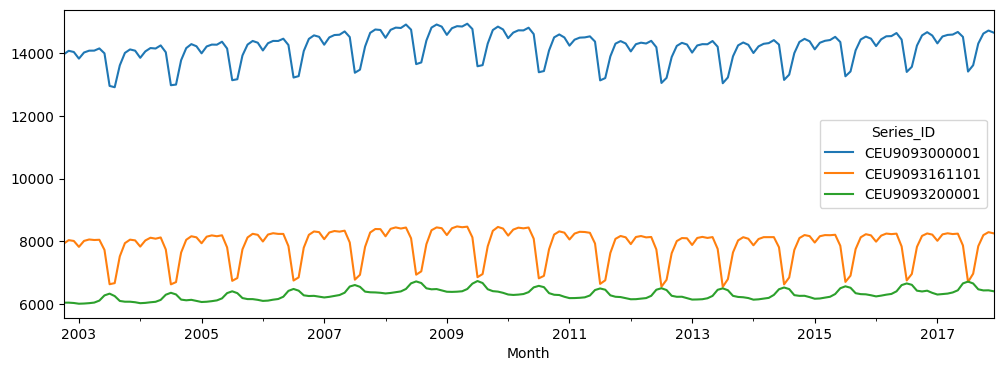

In [39]:
#| fig-align: center
#| label: fig-sim-2
#| fig-cap: Series from bottom right corner of heatmap
ss = [us2_series[x] for x in [143, 144, 145]]
us2.T.loc[:, ss].plot(figsize=(12,4));

## Summary 

We have briefly covered the following time series concepts: Exploratory data
analysis, assessing point forecasts and a few commonly used models. To finish
up the section, we also applied clustering to time series. With today's code,
the model-fitting routines are easier to run. As always, the onus is on us as
analysts to inspect the residuals from the models to understand the time series
we are working with.

## References

### Stats models pages
1. [Main page](https://www.statsmodels.org/dev/tsa.html)
3. [Forecasting with statsmodels](https://www.statsmodels.org/dev/tsa.html#module-statsmodels.tsa.forecasting)
4. [Theta model](https://www.statsmodels.org/dev/examples/notebooks/generated/theta-model.html)

### Forecasting principles and practice

Although the code for this textboook uses R, the concepts are very well
explained. It is written by one of the foremost experts in time series
forecasting methods. The reference is @hyndman2018forecasting.

* [Forecasting: Principles and Practice](https://otexts.com/fpp3/)